In [9]:
import csv
import os
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

In [2]:
class MyLinearUnivariateRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = 0.0

    def fit(self, x, y):
        sx = sum(x)
        sy = sum(y)
        sx2 = sum(i * i for i in x)
        sxy = sum(i * j for (i, j) in zip(x, y))
        n = len(x)

        w1 = (n * sxy - sx * sy) / (n * sx2 - sx * sx)
        w0 = (sy - w1 * sx) / n
        self.intercept_, self.coef_ = w0, w1

    def predict(self, x):
        if isinstance(x[0], list):
            return [self.intercept_ + self.coef_ * val[0] for val in x]
        else:
            return [self.intercept_ + self.coef_ * val for val in x]

In [3]:
class MyLinearBivariateRegression:
    def __init__(self):
        self.w0, self.w1, self.w2 = 0.0, 0.0, 0.0

    def _det(self, m):
        return (m[0][0] * (m[1][1] * m[2][2] - m[1][2] * m[2][1]) -
                m[0][1] * (m[1][0] * m[2][2] - m[1][2] * m[2][0]) +
                m[0][2] * (m[1][0] * m[2][1] - m[1][1] * m[2][0]))

    def fit(self, X, Y):
        n = len(Y)

        if n == 0: 
            return
            
        sum_x1 = sum(x[0] for x in X)
        sum_x2 = sum(x[1] for x in X)
        sum_y = sum(Y)
        sum_x1_sq = sum(x[0]**2 for x in X)
        sum_x2_sq = sum(x[1]**2 for x in X)
        sum_x1_x2 = sum(x[0]*x[1] for x in X)
        sum_x1_y = sum(x[0]*y for x, y in zip(X, Y))
        sum_x2_y = sum(x[1]*y for x, y in zip(X, Y))

        eps = 1e-4

        A00 = n + eps
        A11 = sum_x1_sq + eps
        A22 = sum_x2_sq + eps
        mat_A = [
            [A00, sum_x1, sum_x2],
            [sum_x1, A11, sum_x1_x2],
            [sum_x2, sum_x1_x2, A22]
        ]
        det_A = self._det(mat_A)

        mat_w0 = [
            [sum_y, sum_x1, sum_x2],
            [sum_x1_y, A11, sum_x1_x2],
            [sum_x2_y, sum_x1_x2, A22]
        ]

        mat_w1 = [
            [A00, sum_y, sum_x2],
            [sum_x1, sum_x1_y, sum_x1_x2],
            [sum_x2, sum_x2_y, A22]
        ]


        mat_w2 = [
            [A00, sum_x1, sum_y],
            [sum_x1, A11, sum_x1_y],
            [sum_x2, sum_x1_x2, sum_x2_y]
        ]
        
        if det_A == 0:
            return

        self.w0 = self._det(mat_w0) / det_A
        self.w1 = self._det(mat_w1) / det_A
        self.w2 = self._det(mat_w2) / det_A

    def predict(self, X):
        return [self.w0 + self.w1 * x[0] + self.w2 * x[1] for x in X]

In [4]:
def calculate_manual_metrics(real, computed):
    error_mae = sum(abs(r - c) for r, c in zip(real, computed)) / len(real)
    error_rmse = math.sqrt(sum((r - c) ** 2 for r, c in zip(real, computed)) / len(real))
    return error_mae, error_rmse

In [5]:
def loadDataMultipleFeatures(fileName, inputVariabNames, outputVariabName):
    df = pd.read_csv(fileName)
    
    df = df.dropna(subset=inputVariabNames + [outputVariabName])
    
    inputs = df[inputVariabNames].values.tolist()
    outputs = df[outputVariabName].values.tolist()
    return inputs, outputs

In [6]:
def plot_univariate(train_in, train_out, model, title):
    plt.figure(figsize=(8, 5))
    x_val = [x[0] if isinstance(x, list) else x for x in train_in]
    
    plt.scatter(x_val, train_out, color='blue', label='Data Points', alpha=0.5)
    
    x_range = np.linspace(min(x_val), max(x_val), 100).reshape(-1, 1)
    try:
        y_range = model.predict(x_range)
    except:
        y_range = model.predict([x[0] for x in x_range])
        
    plt.plot(x_range, y_range, color='red', linewidth=2, label='Regression Line')
    plt.title(title)
    plt.xlabel('Feature')
    plt.ylabel('Happiness Score')
    plt.legend()
    plt.show()

def plot_bivariate(train_in, train_out, model, features, title):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    x = np.array([row[0] for row in train_in])
    y = np.array([row[1] for row in train_in])
    z = np.array(train_out)
    
    ax.scatter(x, y, z, color='blue', alpha=0.5)
    
    x_surf, y_surf = np.meshgrid(np.linspace(min(x), max(x), 20), 
                                 np.linspace(min(y), max(y), 20))
    
    mesh_points = np.c_[x_surf.ravel(), y_surf.ravel()]
    z_surf = np.array(model.predict(mesh_points.tolist())).reshape(x_surf.shape)
    
    ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3)
    
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])
    ax.set_zlabel('Happiness Score')
    plt.title(title)
    plt.show()

In [10]:
def train_and_evaluate(name, model, train_in, train_out, val_in, val_out):
    model.fit(train_in, train_out)
    preds = model.predict(val_in)
    
    mae = mean_absolute_error(val_out, preds)
    rmse = math.sqrt(mean_squared_error(val_out, preds))
    
    print(f"  {name:15} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    return preds

def solve_regression_problem(file_name):
    print(f"\n--- Analiza fisier: {file_name} ---")
    
    base_dir = os.path.dirname(__file__) if '__file__' in globals() else os.getcwd()
    file_path = os.path.join(base_dir, file_name)

    if not os.path.exists(file_path):
        print(f"Eroare: Fisierul {file_path} nu exista!")
        return

    experiments = [
        {
            "title": "1. Regresie Univariata (Family -> Happiness)",
            "features": ['Family'],
            "target": 'Happiness.Score'
        },
        {
            "title": "2. Regresie Bivariata (GDP + Freedom -> Happiness)",
            "features": ['Economy..GDP.per.Capita.', 'Freedom'],
            "target": 'Happiness.Score'
        }
    ]

    for exp in experiments:
        print(f"\n{exp['title']}")
        
        inputs, outputs = loadDataMultipleFeatures(file_path, exp['features'], exp['target'])
        
        split_idx = int(0.8 * len(inputs))
        train_in, val_in = inputs[:split_idx], inputs[split_idx:]
        train_out, val_out = outputs[:split_idx], outputs[split_idx:]

        train_and_evaluate("Tool (sklearn)", linear_model.LinearRegression(), 
                           train_in, train_out, val_in, val_out)

        my_model = MyLinearBivariateRegression() if len(exp['features']) > 1 else MyLinearUnivariateRegression()
        
        if len(exp['features']) == 1:
            train_in_manual = [x[0] for x in train_in]
            val_in_manual = [x[0] for x in val_in]
            train_and_evaluate("Cod propriu", my_model, train_in_manual, train_out, val_in_manual, val_out)
            plot_univariate(train_in, train_out, my_model, f"Univariate: {exp['title']}")
        else:
            train_and_evaluate("Cod propriu", my_model, train_in, train_out, val_in, val_out)
            plot_bivariate(train_in, train_out, my_model, exp['features'], f"Bivariate: {exp['title']}")


--- Analiza fisier: v1_world-happiness-report-2017.csv ---

1. Regresie Univariata (Family -> Happiness)
  Tool (sklearn)  -> MAE: 1.9729, RMSE: 2.0077
  Cod propriu     -> MAE: 1.9729, RMSE: 2.0077


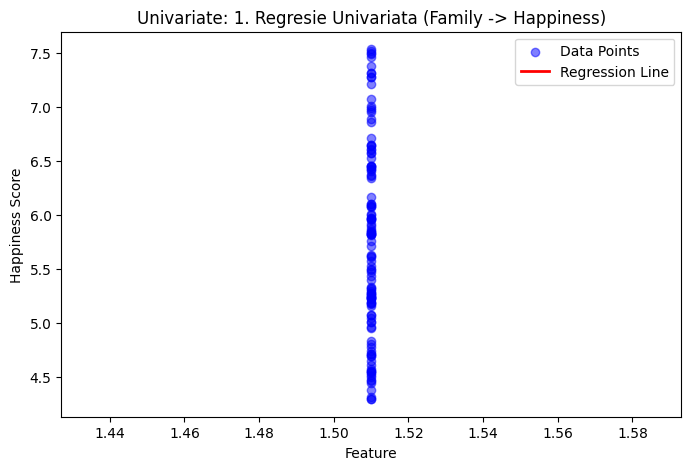


2. Regresie Bivariata (GDP + Freedom -> Happiness)
  Tool (sklearn)  -> MAE: 0.6248, RMSE: 0.7863
  Cod propriu     -> MAE: 0.6248, RMSE: 0.7863


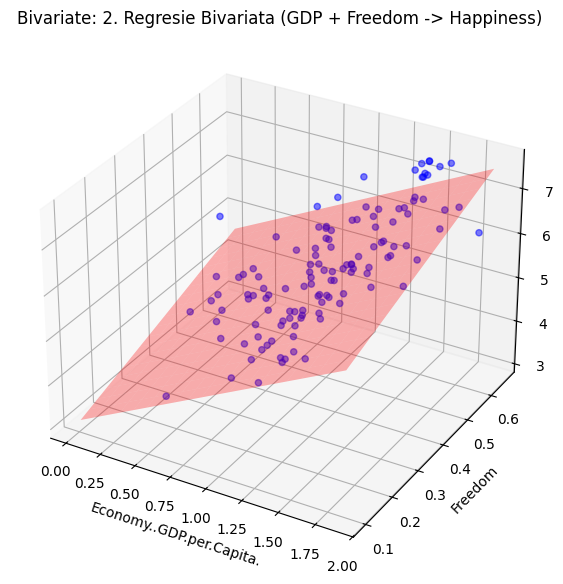


--- Analiza fisier: v2_world-happiness-report-2017.csv ---

1. Regresie Univariata (Family -> Happiness)
  Tool (sklearn)  -> MAE: 0.9686, RMSE: 1.1156
  Cod propriu     -> MAE: 0.9686, RMSE: 1.1156


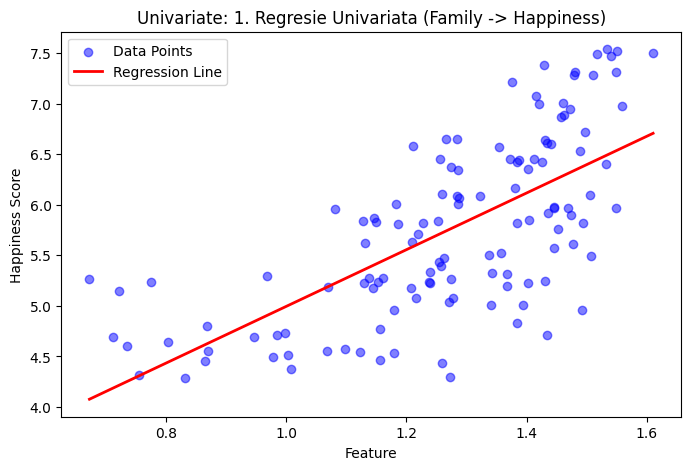


2. Regresie Bivariata (GDP + Freedom -> Happiness)
  Tool (sklearn)  -> MAE: 0.8136, RMSE: 0.9181
  Cod propriu     -> MAE: 0.8106, RMSE: 0.9168


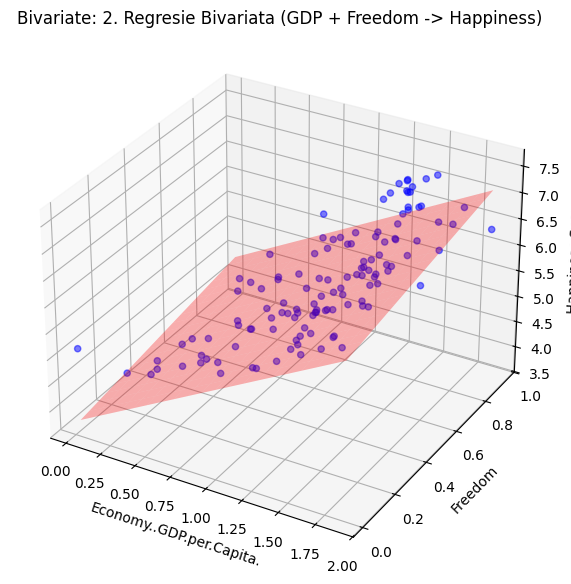


--- Analiza fisier: v3_world-happiness-report-2017.csv ---

1. Regresie Univariata (Family -> Happiness)
  Tool (sklearn)  -> MAE: 0.9686, RMSE: 1.1156
  Cod propriu     -> MAE: 0.9686, RMSE: 1.1156


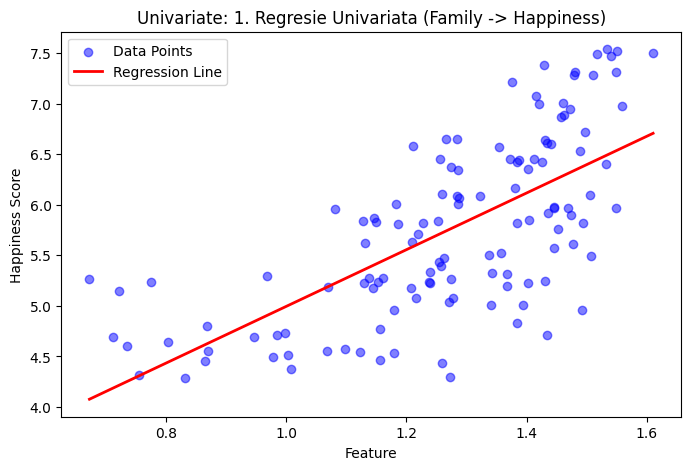


2. Regresie Bivariata (GDP + Freedom -> Happiness)
  Tool (sklearn)  -> MAE: 0.6106, RMSE: 0.7736
  Cod propriu     -> MAE: 0.6106, RMSE: 0.7736


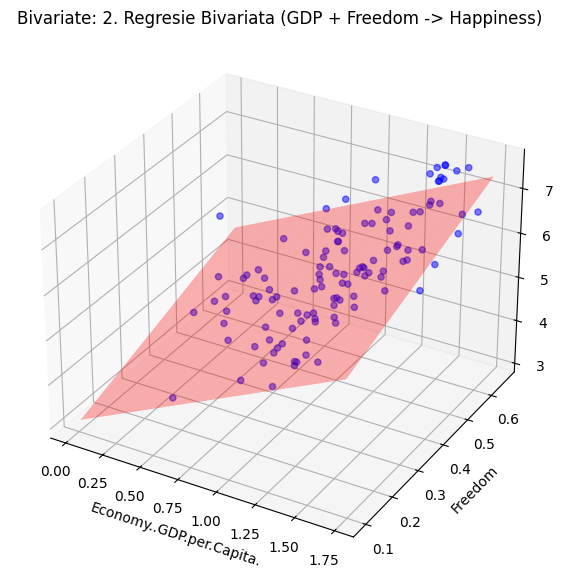

In [11]:
solve_regression_problem('v1_world-happiness-report-2017.csv')
solve_regression_problem('v2_world-happiness-report-2017.csv')
solve_regression_problem('v3_world-happiness-report-2017.csv')